In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('profit_prediction.csv')

In [4]:
df.head()

,Marketing Spend,Administration,Transport,Area,Profit
0,114523.61,136897.80,471784.10,Dhaka,192261.83
1,162597.70,151377.59,443898.53,Ctg,191792.06
2,153441.51,101145.55,407934.54,Rangpur,191050.39
3,144372.41,118671.85,383199.62,Dhaka,182901.99
4,142107.34,91391.77,366168.42,Rangpur,166187.94


In [5]:
df1=pd.get_dummies(df,drop_first=True)
df1.head()

,Marketing Spend,Administration,Transport,Profit,Area_Dhaka,Area_Rangpur
0,114523.61,136897.80,471784.10,192261.83,True,False
1,162597.70,151377.59,443898.53,191792.06,False,False
2,153441.51,101145.55,407934.54,191050.39,False,True
3,144372.41,118671.85,383199.62,182901.99,True,False
4,142107.34,91391.77,366168.42,166187.94,False,True


In [6]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Marketing Spend  50 non-null     float64
 1   Administration   50 non-null     float64
 2   Transport        50 non-null     float64
 3   Profit           50 non-null     float64
 4   Area_Dhaka       50 non-null     bool   
 5   Area_Rangpur     50 non-null     bool   
dtypes: bool(2), float64(4)
memory usage: 1.8 KB


In [7]:
df1=df1.astype({"Area_Dhaka":"int"})
df1=df1.astype({"Area_Rangpur":"int"})

In [8]:
df1.head()

,Marketing Spend,Administration,Transport,Profit,Area_Dhaka,Area_Rangpur
0,114523.61,136897.80,471784.10,192261.83,1,0
1,162597.70,151377.59,443898.53,191792.06,0,0
2,153441.51,101145.55,407934.54,191050.39,0,1
3,144372.41,118671.85,383199.62,182901.99,1,0
4,142107.34,91391.77,366168.42,166187.94,0,1


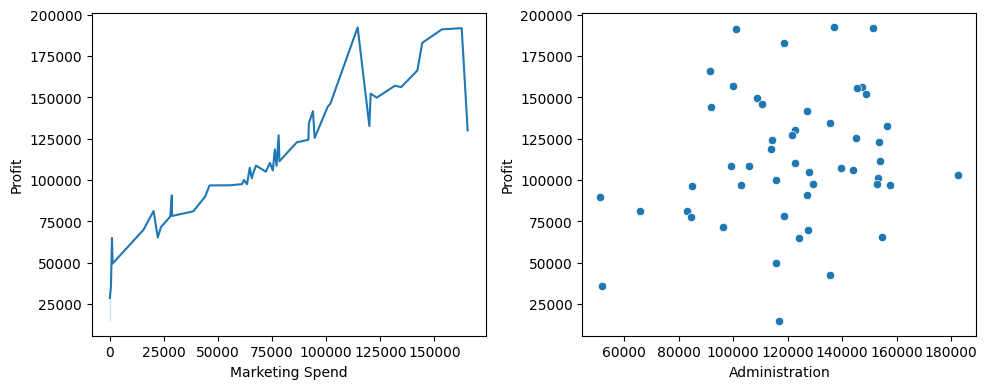

In [9]:
fig,axa=plt.subplots(1,2,figsize=(10,4))
sns.lineplot(df,x='Marketing Spend',y='Profit',ax=axa[0])
sns.scatterplot(df,x='Administration',y='Profit',ax=axa[1])
plt.tight_layout()
plt.show()

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [11]:
x=df1.drop('Profit',axis=1)
y=df1['Profit']

In [12]:
df1.corr()['Profit']

Marketing Spend    0.937948
Administration     0.200717
Transport          0.747766
Profit             1.000000
Area_Dhaka         0.031368
Area_Rangpur       0.116244
Name: Profit, dtype: float64

In [13]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,train_size=0.8,random_state=42)

In [14]:
model=LinearRegression()

In [15]:
model.fit(xtrain,ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
model.intercept_

np.float64(41726.72568243439)

In [17]:
model.coef_

array([ 6.67650761e-01,  1.09115916e-02,  9.05147243e-02, -6.01755713e+02,
       -1.16636540e+03])

* Every 1 rupee increase in Marketing Spend increases Profit by 0.66.
* Every 1 rupee increase in Administration increases 0.01.
* Every 1 rupee increase in Transport Spending increases Profit by 0.09.
* If the business is located in Dhaka, the Profit decreases by 601.75.
* If the business is located in Rangpur, profit decreases by 1,166.36.

In [18]:
y_predicted=model.predict(xtest)
y_pred=model.predict(xtrain)

In [19]:
model.score(xtrain,ytrain)

0.8999067784720345

In [20]:
model.score(xtest,ytest)

0.8389824679943252

In [21]:
from sklearn.metrics import r2_score,mean_squared_error,root_mean_squared_error 

In [22]:
r2_score(ytrain,y_pred)

0.8999067784720345

In [23]:
r2_score(ytest,y_predicted)

0.8389824679943252

In [24]:
mean_squared_error(ytest,y_predicted)

130390721.14438465

In [25]:
r=root_mean_squared_error(ytest,y_predicted)

In [26]:
import numpy as np

In [27]:
target_mean=np.mean(ytest)

In [28]:
MSE_Evaluation=r/target_mean
MSE_Evaluation

np.float64(0.11716917234832495)

**with using Standard Scaler**

In [29]:
from sklearn.preprocessing import StandardScaler

In [30]:
scaler=StandardScaler()

In [31]:
xtrain_scaled=scaler.fit_transform(xtrain)
xtest_scaled=scaler.transform(xtest)
xtrain_scaled
xtest_scaled


array([[ 0.30245367,  0.52942836,  0.14916233, -0.69388867, -0.73379939],
       [-0.82734624, -1.40769369, -0.53560477, -0.69388867, -0.73379939],
       [-0.33181874, -0.20294703, -1.27505783, -0.69388867,  1.36277029],
       [-1.62147425,  0.11103854, -2.06176266,  1.44115338, -0.73379939],
       [ 0.35879726,  0.88291223,  0.41286919,  1.44115338, -0.73379939],
       [-1.63116196, -2.56004955, -2.07854935,  1.44115338, -0.73379939],
       [-0.04987791,  0.84817808, -0.89664846, -0.69388867,  1.36277029],
       [-0.2753597 ,  0.67912498, -0.86215204, -0.69388867, -0.73379939],
       [-0.30191325,  0.29793642, -1.67222209, -0.69388867, -0.73379939],
       [ 0.18462534,  1.19412269, -2.07854935,  1.44115338, -0.73379939]])

In [32]:
model.fit(xtrain_scaled,ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [33]:
train_score=model.score(xtrain_scaled,ytrain)
train_score

0.8999067784720345

In [34]:
test_score=model.score(xtest_scaled,ytest)
test_score

0.8389824679944397

In [35]:
model.coef_

array([31576.53893307,   295.79973447, 10266.09354096,  -281.84724189,
        -556.32083862])

* Every 1 rupee increase in Marketing Spend increases Profit by 31,576.54.
* Every 1 rupee increase in Administration increases 295.80.
* Every 1 rupee increase in Transport Spending increases Profit by 10,266.09.
* If the business is located in Dhaka, the Profit decreases by 281.85.
* If the business is located in Rangpur, profit decreases by 556.32.
